# End-to-End Pipeline: Cost-Sensitive Thresholding vs. Cost-Sensitive Training

Runs the full pipeline from raw data to results. You can do "Run All Cells" and the whole pipeline will run correctly in sequence. This should reproduce the same results reported in the paper.

### Stages:

1. Download dataset
2. Preprocess data
3. Run **Approach 1 (Cost-Sensitive *Thresholding*)**:&nbsp;&nbsp;&nbsp;&nbsp;train 1 model&nbsp;&nbsp;&rarr;&nbsp;&nbsp;calibrate&nbsp;&nbsp;&rarr;&nbsp;&nbsp;evaluate
4. Run **Approach 2 (Cost-Sensitive *Training*)**:&nbsp;&nbsp;&nbsp;&nbsp;train 5 models&nbsp;&nbsp;&rarr;&nbsp;&nbsp;evaluate all
5. Compare A1 vs. A2 vs. baselines
6. Visualize results

> **Jupyter Kernel:** Select the `shock-thresholding` kernel (created by `setup.py`).

In [1]:
%matplotlib inline

import sys
import torch
from config import COST_RATIOS

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f"Python:           {sys.executable}")
print(f"Device:           {device}")
print(f"COST_RATIOS (λ):  {COST_RATIOS}")

Python:           /Users/samernajjar/Desktop/Education/UT_Austin/Masters/Spring_2026/CSML--AI-391M/Final-Project/shock-thresholding/venv/bin/python
Device:           mps
COST_RATIOS (λ):  [1.0, 2.0, 5.0, 10.0, 20.0]


---
## Stage 1: Download Dataset

Downloads two ECG datasets, **VFDB** (\~47.5 MB) and **CUDB** (\~7.9 MB), from PhysioNet into `data/`. Idempotent.

In [2]:
!wget -r -N -c -np -P data/vfdb https://physionet.org/files/vfdb/1.0.0/
!wget -r -N -c -np -P data/cudb https://physionet.org/files/cudb/1.0.0/

--2026-04-20 14:52:03--  https://physionet.org/files/vfdb/1.0.0/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘data/vfdb/physionet.org/files/vfdb/1.0.0/index.html’

physionet.org/files     [ <=>                ]  12.95K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-04-20 14:52:06 (6.17 GB/s) - ‘data/vfdb/physionet.org/files/vfdb/1.0.0/index.html’ saved [13256]

Loading robots.txt; please ignore errors.
--2026-04-20 14:52:06--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK

    The file is already fully retrieved; nothing to do.

--2026-04-20 14:52:06--  https://physionet.org/files/vfdb/1.0.0/418.atr
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 304

---
## Stage 2: Preprocess Data

Segments VFDB (train/valid) and CUDB (test) into 2-second windows, handles NaNs, normalizes, and saves to `data/splits.npz`.

In [3]:
!{sys.executable} preprocess_data.py

Preprocessing data...

VFDB Validation Set Proportion (desired proportion = 0.2):
  - shockable:      19.98%
  - non-shockable:  18.19%
  - overall:        18.51%

---------------------------------------------------------
Split  Database  Records  Shockable  Non-Shockable  Ratio
---------------------------------------------------------
Train  VFDB           18      3,372         15,668  1:4.6
Valid  VFDB            4        842          3,483  1:4.1
Test   CUDB           35      1,825          6,889  1:3.8
---------------------------------------------------------


---
## Stage 3: Run Approach 1 (Cost-Sensitive *Thresholding*)

Trains one model with standard BCE loss, calibrates with temperature scaling, then evaluates at Elkan's optimal threshold

$$
\theta^*(\lambda) = \frac{1}{\lambda+1}
$$

for each $\lambda$. Saves predictions to `results/a1.npz`.

In [4]:
!{sys.executable} Approach_1.py --yes

╔══════════════════════════════════════════════════════════════════════╗
║               APPROACH 1: COST-SENSITIVE THRESHOLDING                ║
╠══════════════════════════════════════════════════════════════════════╣
║   • Train 1 model with pos_weight=1.0                                ║
║   • Calibrate via temperature scaling                                ║
║   • Evaluate at Elkan's optimal threshold θ*(λ) = 1/(λ+1) for        ║
║        λ = 1.0, 2.0, 5.0, 10.0, 20.0                                 ║
║                                                                      ║
║ Saving calibrated model to:  calibrated/                             ║
╚══════════════════════════════════════════════════════════════════════╝



[Using device "mps"]

----------------------------------------------------------------------
Training config:
    batch_size = 64     
    lr = 0.001          (reduced on plateau)
    epochs = 20         (starting from epoch 1)
    pos_weight = 1.0    
--------------

---
## Stage 4: Run Approach 2 (Cost-Sensitive *Training*)

Trains 5 models (one per $\lambda$) with `pos_weight=λ`, then evaluates each at the default threshold $\theta=0.5$. Saves predictions to `results/a2.npz`.

In [5]:
!{sys.executable} Approach_2.py --yes

╔══════════════════════════════════════════════════════════════════════╗
║                 APPROACH 2: COST-SENSITIVE TRAINING                  ║
╠══════════════════════════════════════════════════════════════════════╣
║   • Train 5 cost-sensitive models with                               ║
║        pos_weight = λ = 1.0, 2.0, 5.0, 10.0, 20.0                    ║
║   • Evaluate each model at default threshold θ=0.5 (no calibration)  ║
║                                                                      ║
║ Saving all models to:  cost_sensitive/                               ║
╚══════════════════════════════════════════════════════════════════════╝



[Using device "mps"]

----------------------------------------------------------------------
Training config:
    batch_size = 64     
    lr = 0.001          (reduced on plateau)
    epochs = 20         (starting from epoch 1)
    pos_weight = 1.0    
----------------------------------------------------------------------

* Checkpoint sa

---
## Stage 5: Compare A1 vs. A2 vs. Baselines

Our primary performance metric is the **Expected Cost EC($\lambda$)** (which we want to minimize):

$$
\text{EC}(\lambda) = \frac{\text{FP} + \lambda\cdot\text{FN}}{N}
$$

where $N$ is the dataset size. Thus we run a **paired bootstrap test** (`B=10,000`) on 

$$
\Delta\text{EC}(\lambda) = \text{EC}_{\text{A1}}(\lambda) − \text{EC}_{\text{A2}}(\lambda)
$$

at each $\lambda$, plus comparison against two trivial baselines (`"always predict pos"` and `"always predict neg"`). The goal is to see if the performance difference between A1 and A2 is statistically significant, and if they out-perform trivial baselines.

In [6]:
!{sys.executable} compare.py

════════════════════════════════════════════════════════════════════════════════════════════════════
A1 vs. A2: Paired Bootstrap Test (B=10,000)
λ = 1.0
──────────────────────────────────────
Metric                 A1           A2
──────────────────────────────────────
EC(λ)             0.15814      0.15814  (tie)
FPR               0.14864      0.14864
FNR               0.19397      0.19397
TP                   1471         1471
FP                   1024         1024
TN                   5865         5865
FN                    354          354
──────────────────────────────────────
ΔEC(λ) = +0.00000  (ΔEC = A1 - A2)
95% CI: [+0.00000, +0.00000]
p = 1.00000

Trivial Baselines
λ = 1.0
────────────────────────────────────────────────────────────────────
Metric          Trivial Pos    Trivial Neg           A1           A2
────────────────────────────────────────────────────────────────────
EC(λ)               0.79057        0.20943      0.15814      0.15814
FPR                 1.00000     

---
## Stage 6: Visualize Results

Generates and saves all visualizations to `viz/`.

Saved:  viz/reliability_diagram.pdf
Saved:  viz/ec_curves.pdf
Saved:  viz/elkan_curve.pdf
Saved:  viz/cs_conf_curve.pdf


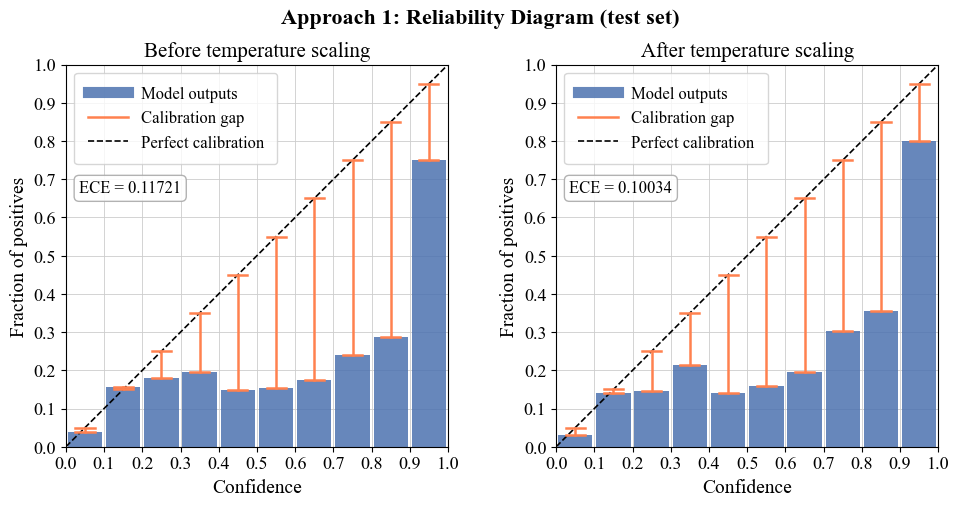

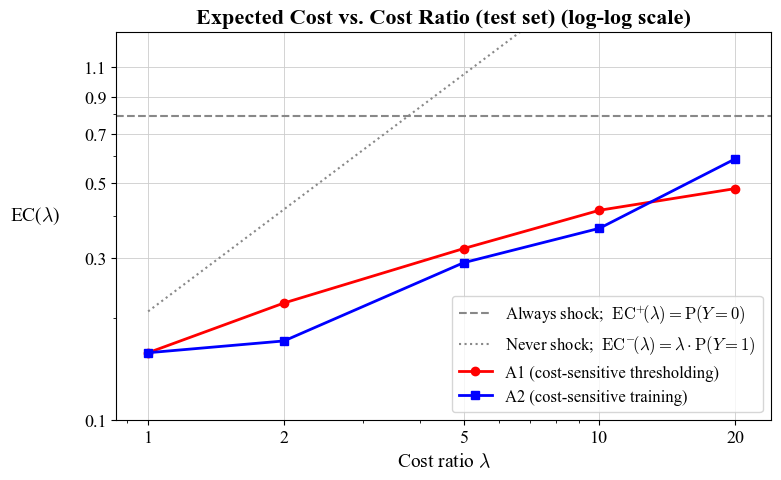

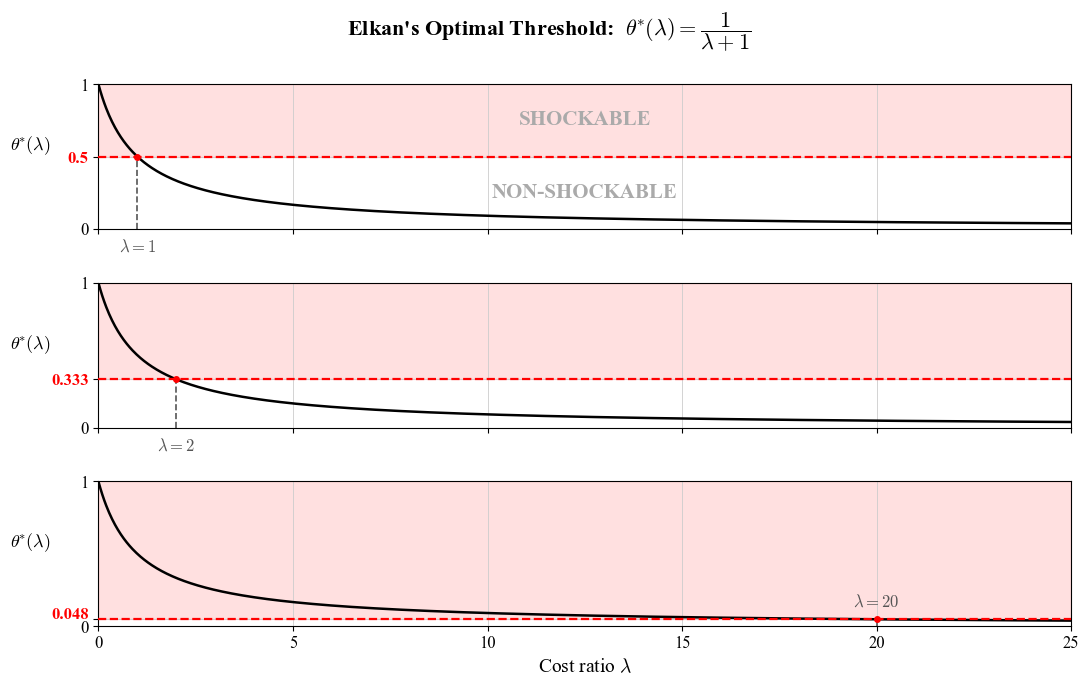

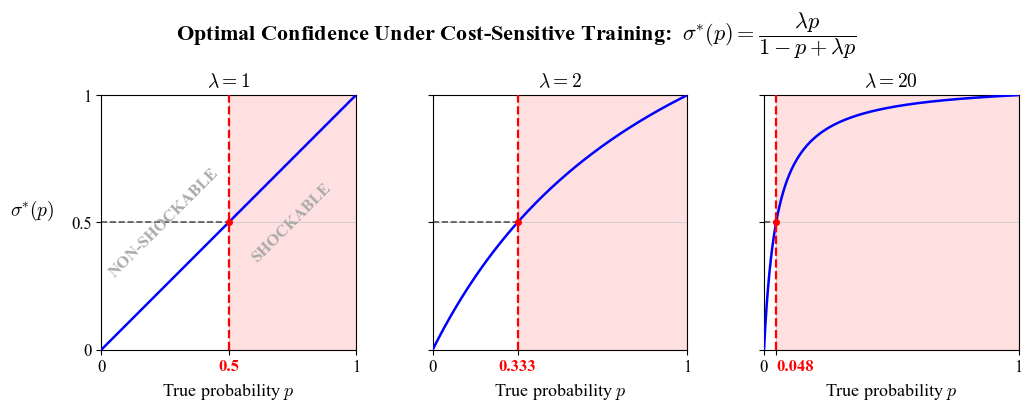

In [7]:
from viz import (
    plot_reliability_diagram, 
    plot_ec_curves, 
    plot_elkan_curve, 
    plot_cs_conf_curve
)

_ = plot_reliability_diagram()
_ = plot_ec_curves()
_ = plot_elkan_curve()
_ = plot_cs_conf_curve()